# Explore Dataset + Mask Collator

Pulls a shard from R2, wires it through `make_dataset` + `MaskCollator`, then visualizes a clip and its V-JEPA encoder mask.

In [115]:
import io
import os

import boto3
import numpy as np
import torch
from dotenv import load_dotenv
from IPython.display import Image as IPyImage
from PIL import Image as PILImage
from torch.utils.data import DataLoader

from agent_1.data.dataset import make_dataset
from agent_1.models.vjepa.mask import MaskCollator

load_dotenv()

True

In [116]:
BUCKET_NAME = "datasets"
PREFIX = "vision_encoder/DMG/longplays/"

# Clip / patch geometry — must match the encoder's patch_dim.
# Game Boy frames are 160 wide x 144 tall, so H=144, W=160.
CLIP_T, CLIP_H, CLIP_W = 16, 144, 160
PATCH_T, PATCH_H, PATCH_W = 2, 16, 16
GRID_SIZE = (CLIP_T // PATCH_T, CLIP_H // PATCH_H, CLIP_W // PATCH_W)

# V-JEPA2 uses spatial_scale=0.7 on a 16×16 grid (256 patches), giving ~3-patch
# block margins per dimension. Our 9×10 grid (90 patches) requires 0.4 to achieve
# the same relative margins (~3 patches), otherwise two sub-masks nearly always
# overlap entirely and leave the encoder with <10% of patches as context.
MASK_CONFIGS = [
    {"grid_size": GRID_SIZE, "mask_area_ratio": 0.4, "mask_ar_range": (0.75, 1.5), "num_sub_masks": 1, "allow_overlap": False},
    {"grid_size": GRID_SIZE, "mask_area_ratio": 0.125, "mask_ar_range": (0.75, 1.5), "num_sub_masks": 4, "allow_overlap": False},
]

BATCH_SIZE = 4
GRID_SIZE

(8, 9, 10)

In [117]:
s3 = boto3.client(
    "s3",
    endpoint_url=os.environ["R2_ENDPOINT_URL"],
    aws_access_key_id=os.environ["R2_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["R2_SECRET_ACCESS_KEY"],
)

resp = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix=PREFIX, MaxKeys=1)
shard_key = resp["Contents"][0]["Key"]
shard_url = f"s3://{BUCKET_NAME}/{shard_key}"
print(f"Streaming from {shard_url}")

Streaming from s3://datasets/vision_encoder/DMG/longplays/000000.tar


In [118]:
dataset = make_dataset(shard_url, shuffle_buffer=0, shardshuffle=False)
collator = MaskCollator(MASK_CONFIGS)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, collate_fn=collator)

batch = next(iter(loader))
print({k: (v.shape if torch.is_tensor(v) else type(v).__name__) for k, v in batch.items() if k not in ("masks_enc", "masks_pred")})
for i, (me, mp) in enumerate(zip(batch["masks_enc"], batch["masks_pred"])):
    print(f"cfg {i}: masks_enc {tuple(me.shape)}  masks_pred {tuple(mp.shape)}")

{'video': torch.Size([4, 16, 1, 144, 160]), 'source_video': 'list', 'clip_number': torch.Size([4]), 'start_frame': torch.Size([4]), 'end_frame': torch.Size([4]), '__key__': 'list'}
cfg 0: masks_enc (4, 440)  masks_pred (4, 280)
cfg 1: masks_enc (4, 336)  masks_pred (4, 384)


## View a clip

Each clip is `(T, C, H, W)`. Display all `T` frames as a horizontal strip.

Donkey_Kong_Land_III clip 403


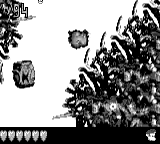

In [119]:
SAMPLE_IDX = 1
MASK_CFG_IDX = 0
FRAME_MS = 100  # ms per frame in the GIF

clip = batch["video"][SAMPLE_IDX]  # (T, C, H, W) uint8
frames = clip.squeeze(1).cpu().numpy()  # (T, H, W) for grayscale

print(f"{batch['source_video'][SAMPLE_IDX]} clip {batch['clip_number'][SAMPLE_IDX].item()}")

images = [PILImage.fromarray(f) for f in frames]
buf = io.BytesIO()
images[0].save(buf, format="GIF", save_all=True, append_images=images[1:], duration=FRAME_MS, loop=0)
IPyImage(data=buf.getvalue())

## View the mask for the clip

Build a per-patch label — **encoder context** (bright), **predictor target** (dim), or **dropped** (black, lost to min-keep truncation) — then upsample to pixel space.

cfg 0: enc 440 (61%)  pred 280 (39%)  dropped 0 (0%)
cfg 1: enc 336 (47%)  pred 384 (53%)  dropped 0 (0%)
top: raw  |  middle: cfg 0  |  bottom: cfg 1
bright = encoder context  |  dim = predictor target  |  black = dropped


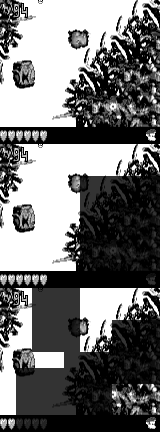

In [120]:
T_p, H_p, W_p = GRID_SIZE
num_patches = T_p * H_p * W_p

ALPHA_ENC  = 1.0   # encoder context  — full brightness
ALPHA_PRED = 0.2   # predictor target — dimmed
ALPHA_DROP = 0.0   # dropped patches  — black (lost to min-keep truncation)

rows = [frames]
for cfg_idx, (me, mp) in enumerate(zip(batch["masks_enc"], batch["masks_pred"])):
    enc_idx  = me[SAMPLE_IDX]
    pred_idx = mp[SAMPLE_IDX]

    alpha_flat = torch.full((num_patches,), ALPHA_DROP)
    alpha_flat[pred_idx] = ALPHA_PRED
    alpha_flat[enc_idx]  = ALPHA_ENC

    alpha = (
        alpha_flat.view(T_p, H_p, W_p)
            .repeat_interleave(PATCH_T, dim=0)
            .repeat_interleave(PATCH_H, dim=1)
            .repeat_interleave(PATCH_W, dim=2)
    ).numpy()

    masked_frames = (frames.astype(np.float32) * alpha).clip(0, 255).astype(np.uint8)

    n_enc  = len(enc_idx)
    n_pred = len(pred_idx)
    n_drop = num_patches - n_enc - n_pred
    print(
        f"cfg {cfg_idx}: "
        f"enc {n_enc} ({n_enc/num_patches:.0%})  "
        f"pred {n_pred} ({n_pred/num_patches:.0%})  "
        f"dropped {n_drop} ({n_drop/num_patches:.0%})"
    )
    rows.append(masked_frames)

stacked = np.concatenate(rows, axis=1)  # (T, N*H, W)
print("top: raw  |  middle: cfg 0  |  bottom: cfg 1")
print("bright = encoder context  |  dim = predictor target  |  black = dropped")

images = [PILImage.fromarray(f) for f in stacked]
buf = io.BytesIO()
images[0].save(buf, format="GIF", save_all=True, append_images=images[1:], duration=FRAME_MS, loop=0)
IPyImage(data=buf.getvalue())